<a href="https://colab.research.google.com/github/Rony2019-2023/secure-cxr-detection-gbm-/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from skimage.io import imread
from skimage.transform import resize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC, BinaryAccuracy
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Define the directory paths for positive and negative images
covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/COVID-19'
non_covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/Normal'

In [ ]:
# Load COVID-19 images and create label array
covid_images = []
covid_labels = []
for img_name in os.listdir(covid_dir):
    img_path = os.path.join(covid_dir, img_name)
    img = imread(img_path)
    img_resized = resize(img, (256, 256)) # Resize image to same dimensions
    covid_images.append(img_resized)
    covid_labels.append(1) # Label COVID-19 images as 1

In [ ]:
# Load non-COVID-19 images and create label array
non_covid_images = []
non_covid_labels = []
for img_name in os.listdir(non_covid_dir):
    img_path = os.path.join(non_covid_dir, img_name)
    img = imread(img_path)
    img_resized = resize(img, (256, 256)) # Resize image to same dimensions
    non_covid_images.append(img_resized)
    non_covid_labels.append(0) # Label non-COVID-19 images

In [ ]:
# Combine COVID-19 and non-COVID-19 images and labels into arrays
images = np.array(covid_images + non_covid_images)
labels = np.array(covid_labels + non_covid_labels)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [ ]:
# Define input shape
input_shape = X_train.shape[1:]


In [ ]:
# Create RNN model
model = Sequential([
    LSTM(64, input_shape=input_shape),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [ ]:

# Compile model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[Precision(name='precision'),
                       Recall(name='recall'),
                       BinaryAccuracy(name='accuracy'),
                       AUC(name='auc')])

In [ ]:
# Train model
history = model.fit(X_train, y_train, batch_size=16, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10
48/48 [==============================] - 10s 154ms/step - loss: 0.2828 - precision: 0.0000e+00 - recall: 0.0000e+00 - accuracy: 0.9141 - auc: 0.4792 - val_loss: 0.1656 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_accuracy: 0.9585 - val_auc: 0.7861
Epoch 2/10
48/48 [==============================] - 7s 136ms/step - loss: 0.2180 - precision: 0.0000e+00 - recall: 0.0000e+00 - accuracy: 0.9323 - auc: 0.8030 - val_loss: 0.1603 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_accuracy: 0.9585 - val_auc: 0.7828
Epoch 3/10
48/48 [==============================] - 6s 118ms/step - loss: 0.1952 - precision: 0.0000e+00 - recall: 0.0000e+00 - accuracy: 0.9323 - auc: 0.8361 - val_loss: 0.1342 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_accuracy: 0.9585 - val_auc: 0.8162
Epoch 4/10
48/48 [==============================] - 8s 157ms/step - loss: 0.1814 - precision: 1.0000 - recall: 0.0192 - accuracy: 0.9336 - auc: 0.8416 - val_loss: 0.1365 - val_precisi

In [ ]:
# Evaluate model
loss, precision, recall, accuracy, auc = model.evaluate(X_test, y_test)

# Predict on test set
y_pred_proba = model.predict(X_test)

# Round predicted probabilities to obtain predicted classes
y_pred = y_pred_proba.round()

# Compute F1 score and specificity
f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Print evaluation metrics
print('Loss:', loss)
print('Precision:', precision)
print('Recall:', recall)
print('Accuracy:', accuracy)
print('AUC:', auc)
print('F1 score:', f1)
print('Specificity:', specificity)

7/7 [==============================] - 1s 77ms/step
Loss: 0.12863890826702118
Precision: 0.0
Recall: 0.0
Accuracy: 0.9585492014884949
AUC: 0.8692567348480225
F1 score: 0.0
Specificity: 1.0


7/7 [==============================] - 1s 74ms/step


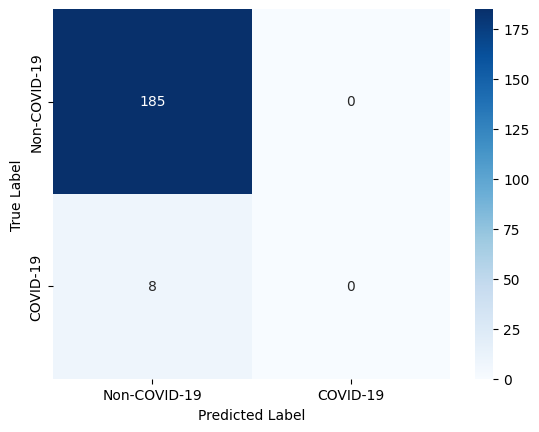

In [ ]:
# Get predictions
y_pred = model.predict(X_test).round()

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define labels for the plot
labels = ['Non-COVID-19', 'COVID-19']

# Create heatmap plot
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

7/7 [==============================] - 1s 78ms/step


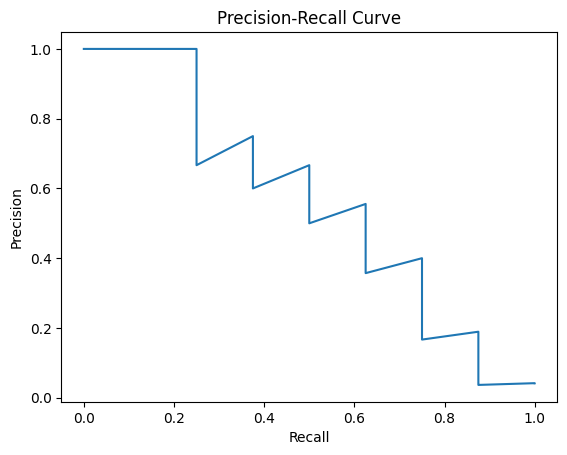

In [ ]:
# Get model predictions on test data
y_pred = model.predict(X_test)

# Calculate precision-recall curve values
precision, recall, _ = precision_recall_curve(y_test, y_pred)

# Plot precision-recall curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

7/7 [==============================] - 1s 117ms/step


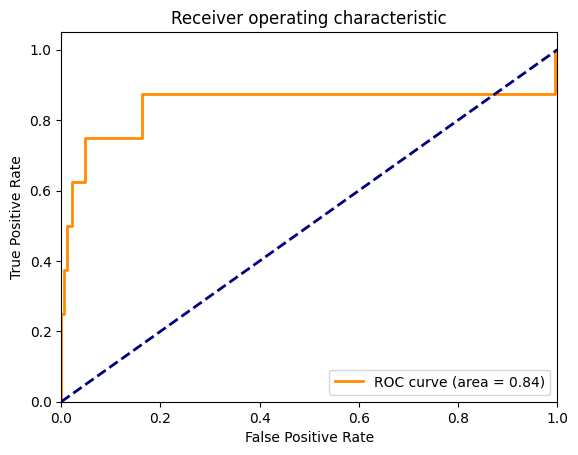

In [ ]:
# Predict probabilities for the test set
y_pred_proba = model.predict(X_test)

# Compute ROC curve and ROC area for each class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

7/7 [==============================] - 1s 129ms/step


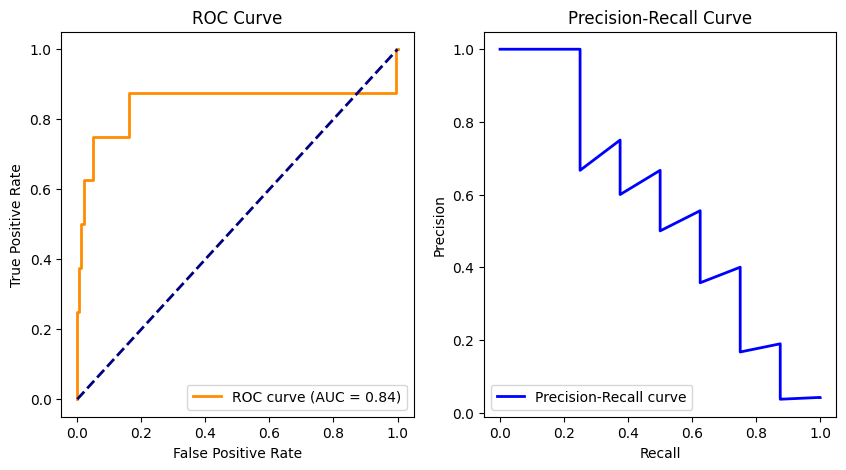

In [ ]:
# Predict probabilities for the test set
y_pred_proba = model.predict(X_test)

# Compute precision-recall curve values
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

# Compute ROC curve values
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

# Compute ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot ROC curve
axs[0].plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
axs[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_ylabel('True Positive Rate')
axs[0].set_title('ROC Curve')
axs[0].legend(loc="lower right")

# Plot precision-recall curve
axs[1].plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
axs[1].set_title('Precision-Recall Curve')
axs[1].legend(loc="lower left")

# Show the plots
plt.show()